In [3]:
# import os
# import sys
# import math
# import logging
# from pathlib import Path
import psignifit as pf
import psignifit.priors as priors

import plotly
import plotly.express as px
import plotly.graph_objs as go
from plotly.subplots import make_subplots

from tqdm import tqdm

import numpy as np
import scipy as sp
from scipy.stats import gamma, lognorm, norm

import sklearn
from sklearn.linear_model import LinearRegression as LinReg
import statsmodels.api as sm
from statsmodels.formula.api import ols

%load_ext autoreload
%autoreload 2

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'


import pandas as pd
pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)

In [102]:
from psychoanalyze import data
import json
from datetime import datetime
from psychoanalyze.plot import template

In [5]:
df = pd.read_csv('../data/3-interim/curves.csv')

## Figure 0 - Impedances

In [97]:
dfz = pd.read_csv('../data/1-normalized/impedances.csv')
dfz['Date'] = pd.to_datetime(dfz['Date'])
dfz.loc[dfz['Monkey']=='U','Days'] = (dfz['Date'] - pd.to_datetime('2016-06-24')).dt.days
dfz.loc[dfz['Monkey']=='Y','Days'] = (dfz['Date'] - pd.to_datetime('2016-03-11')).dt.days
dfz.loc[dfz['Monkey']=='Z','Days'] = (dfz['Date'] - pd.to_datetime('2016-09-16')).dt.days

In [78]:
# dfz['mean'] = dfz.loc[:,'1':'8'].mean(axis=1)
# dfz['std'] = dfz.loc[:,'1':'8'].std(axis=1)

In [98]:
dfz = dfz.melt(id_vars=['Days','Monkey','Date'], var_name='Channel', value_name='1 KHz Impedance').sort_values(by='Days')

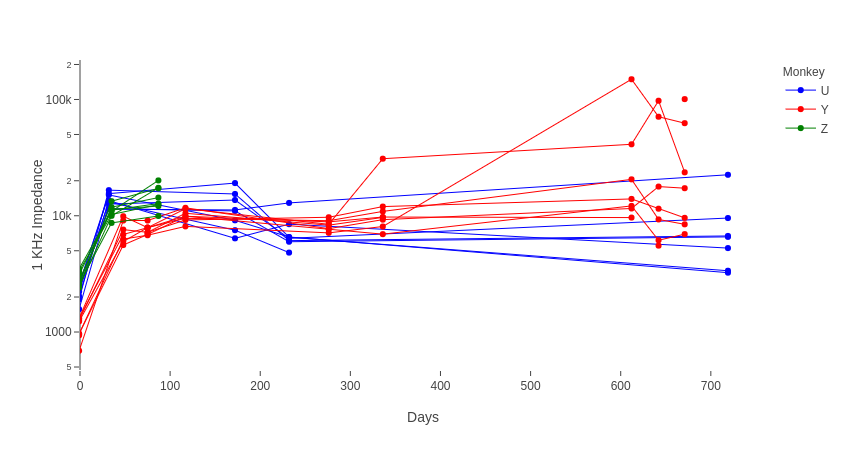

In [104]:
fig = px.line(dfz,color='Monkey',x='Days',y='1 KHz Impedance', line_group='Channel',
             category_orders={'Monkey':['U','Y','Z']}, template=template)
fig.update_traces(line_width=1, mode='lines+markers')
fig.update_yaxes(type='log')

### Figure 1a - All Monkeys, Single Channel

In [21]:
filters = {
    'experiment_type': 'detection', 
    'values':{
        'varparam': 'Amp', 
        'Channel(s)':'1',
        'base':200,
    }
}
df1a = data.filter(df, **filters)
df1a.to_csv('../data/4-external/fig1a.csv')

### Figure 1b - Monkey U, All Channels

In [27]:
filters = {
    'experiment_type': 'detection',
    'values':{
        'varparam': 'Amp',
        'base':200, 
        'Monkey':'U', 
        'Ret Chan Mask':['10000000','01000000','00100000','00010000','11000000','01100000','00110000','10010000','11110000']
    }
}
df1b = data.filter(df, **filters)
df1b.to_csv('../data/4-external/fig1b.csv')

### Figure 1c - Monkey Y, All Channels

In [29]:
filters = {
    'experiment_type': 'detection',
    'values':{
        'varparam': 'Amp',
        'base':200, 
        'Monkey':'Y', 
        'Ret Chan Mask':['10000000','01000000','00100000','00010000','11000000','01100000','00110000','10010000','11110000']
    }
}
df1c = data.filter(df, **filters)
df1c.to_csv('../data/4-external/fig1c.csv')

## Figure 2 - Difference Thresholds

### Figure 2a - All Monkeys, Channels for Amplitude Dimension

In [134]:
filters = {
    'experiment_type': 'discrimination',
    'values': {
        'varparam': 'Amp',
        'Act Chan Mask':'00001111',
        'Ret Chan Mask':['00010000','10000000','00100000','0100000'], 
        'base':200,
    },
    'ranges': {
        'Days':[100,1000],
        'Ref Amp':[0,1200],
    }
}
df2a = data.filter(df, **filters)
groups = ['Monkey','Ref Amp']
summary = df2a.groupby(groups).describe()
summary.to_csv('../data/4-external/fig2a.csv')
regressions = data.regress_groups(df2a,groups)
reg_data = json.dumps(regressions)
f = open("../data/4-external/fig2a_regressions.json","w")
f.write(reg_data)
f.close()

### Figure 2b - Monkey Y by channel

In [139]:
filters = {
    'experiment_type': 'discrimination', 
    'values': {
        'Monkey': 'Y', 
        'varparam': 'Amp',
        'Act Chan Mask':'00001111',
        'Ret Chan Mask':['00010000','10000000','00100000','0100000'], 
        'base':200
    }
}
df2b = data.filter(df, **filters)
groups = ['Monkey','Ref Amp']
summary = df2b.groupby(groups)['location'].describe()
summary.head()
summary.to_csv('../data/4-external/fig2b.csv')
regressions = data.regress_groups(df2b,['Monkey','Ref Amp'])
reg_data = json.dumps(regressions)
f = open("../data/4-external/fig2b_regressions.json","w")
f.write(reg_data)
f.close()